In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("part_5_customer_ltv_prediction.csv.xlsx")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

  CustomerID  Age  AnnualIncome  WebsiteVisits  AppSessions  PreviousOrders  \
0   LTV00001   33      64196.02            145           61              19   
1   LTV00002   46      69889.53            153          111               2   
2   LTV00003   20      83269.51            175          112              34   
3   LTV00004   44      79914.63             22           80               0   
4   LTV00005   26      84091.39             24          166              12   

   AverageOrderValue  DaysSinceLastPurchase  ReturnRate  CancellationRate  \
0            1403.79                    242       0.136             0.028   
1             988.47                    223       0.126             0.067   
2            2386.24                    101       0.026             0.087   
3            1121.87                     98       0.037             0.004   
4            1942.48                    256       0.052             0.004   

  LoyaltyTier DiscountUsedLastCampaign  Year1Spending  FutureS

# Business Problem Understanding

Customer Lifetime Value (CLV) refers to the total value a customer is expected to bring to a business over the course of their relationship.

Increasing LTV is important because retaining existing customers is usually more cost-effective than acquiring new ones.

Unlike one-time sales, CLV focuses on the long-term revenue a customer can generate.

By predicting future spending, the company can identify valuable customers, target them with personalized offers, and improve profitability.

This project uses customer behavior data to estimate future spending and support long-term revenue growth.

# Data Understanding

Each row in the dataset represents one customer.

## Important Columns

- CustomerID: unique customer identifier
- Age: age of the customer
- AnnualIncome: yearly income
- WebsiteVisits: number of website visits
- AppSessions: number of app sessions
- PreviousOrders: number of previous orders
- AverageOrderValue: average value of each order
- DaysSinceLastPurchase: recency measure
- ReturnRate: rate of product returns
- CancellationRate: rate of cancelled orders
- LoyaltyTier: customer loyalty segment
- DiscountUsedLastCampaign: whether the customer used a discount
- Year1Spending: spending in the first year
- FutureSpending: target variable for prediction

## Numerical Columns
Age, AnnualIncome, WebsiteVisits, AppSessions, PreviousOrders, AverageOrderValue, DaysSinceLastPurchase, ReturnRate, CancellationRate, Year1Spending, FutureSpending

## Categorical Columns
LoyaltyTier, DiscountUsedLastCampaign

## Target Variable
FutureSpending

## Problem Type
This is a regression problem because the target variable is continuous.

## Why Supervised Learning?
The dataset has labeled future spending values, so the model learns from historical examples.

In [3]:
print("Duplicate rows:", df.duplicated().sum())
print(df.isnull().sum())

Duplicate rows: 0
CustomerID                   0
Age                          0
AnnualIncome                 9
WebsiteVisits                0
AppSessions                  0
PreviousOrders               0
AverageOrderValue           10
DaysSinceLastPurchase        0
ReturnRate                   0
CancellationRate             0
LoyaltyTier                  0
DiscountUsedLastCampaign     0
Year1Spending                0
FutureSpending               0
dtype: int64


In [4]:
df = df.drop_duplicates()

# Fill missing numeric values with median
df["AnnualIncome"] = df["AnnualIncome"].fillna(df["AnnualIncome"].median())
df["AverageOrderValue"] = df["AverageOrderValue"].fillna(df["AverageOrderValue"].median())

print(df.isnull().sum())

CustomerID                  0
Age                         0
AnnualIncome                0
WebsiteVisits               0
AppSessions                 0
PreviousOrders              0
AverageOrderValue           0
DaysSinceLastPurchase       0
ReturnRate                  0
CancellationRate            0
LoyaltyTier                 0
DiscountUsedLastCampaign    0
Year1Spending               0
FutureSpending              0
dtype: int64


# Data Cleaning

The dataset had a small number of missing values in AnnualIncome and AverageOrderValue.

These were filled using the median to avoid distortion from outliers.

Duplicate rows were removed to ensure accurate analysis.

The dataset was then prepared for feature engineering and regression modeling.

In [5]:
df["TotalEngagement"] = df["WebsiteVisits"] + df["AppSessions"]
df["SpendingGrowth"] = df["FutureSpending"] - df["Year1Spending"]
df["SpendingGrowthRate"] = df["SpendingGrowth"] / (df["Year1Spending"] + 1)
df["OrderIntensity"] = df["PreviousOrders"] / (df["DaysSinceLastPurchase"] + 1)
df["NetEngagementScore"] = (
    df["WebsiteVisits"] +
    df["AppSessions"] +
    df["PreviousOrders"] -
    (df["ReturnRate"] * 100) -
    (df["CancellationRate"] * 100)
)

print(df.head())

  CustomerID  Age  AnnualIncome  WebsiteVisits  AppSessions  PreviousOrders  \
0   LTV00001   33      64196.02            145           61              19   
1   LTV00002   46      69889.53            153          111               2   
2   LTV00003   20      83269.51            175          112              34   
3   LTV00004   44      79914.63             22           80               0   
4   LTV00005   26      84091.39             24          166              12   

   AverageOrderValue  DaysSinceLastPurchase  ReturnRate  CancellationRate  \
0            1403.79                    242       0.136             0.028   
1             988.47                    223       0.126             0.067   
2            2386.24                    101       0.026             0.087   
3            1121.87                     98       0.037             0.004   
4            1942.48                    256       0.052             0.004   

  LoyaltyTier DiscountUsedLastCampaign  Year1Spending  FutureS

# Feature Engineering

The following features were created:

## TotalEngagement
Combines website visits and app sessions to capture total customer interaction.

## SpendingGrowth
Measures how much future spending changes compared to Year1Spending.

## SpendingGrowthRate
Shows the proportional growth in spending.

## OrderIntensity
Measures how frequently a customer places orders relative to how recently they last purchased.

## NetEngagementScore
Combines positive engagement signals and subtracts negative behavior such as returns and cancellations.

These features help the model and the business better understand customer value and future spending potential.

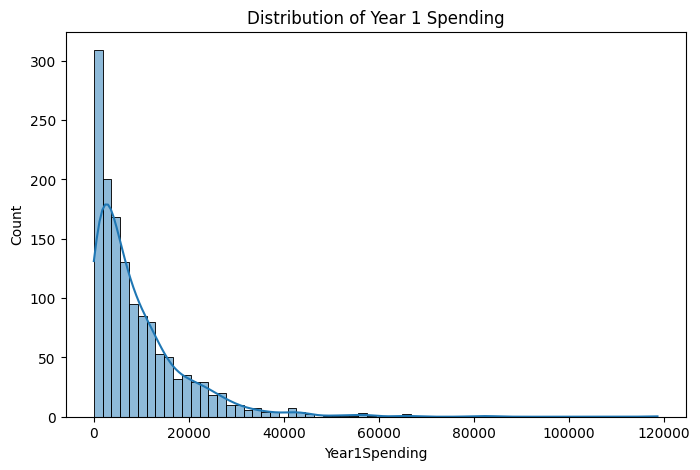

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Year1Spending"], kde=True)
plt.title("Distribution of Year 1 Spending")
plt.xlabel("Year1Spending")
plt.ylabel("Count")
plt.show()

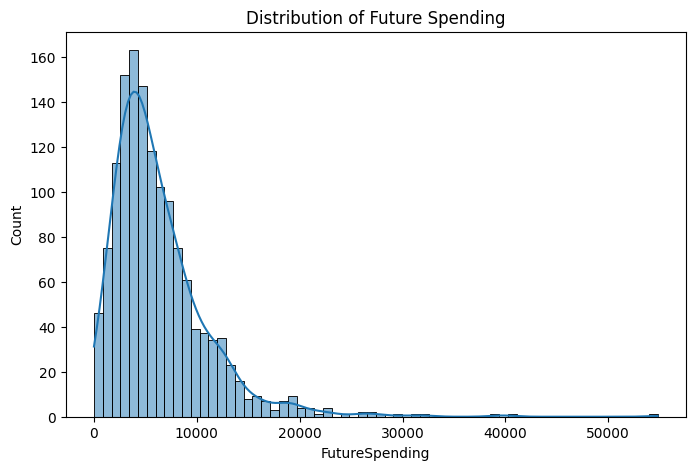

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["FutureSpending"], kde=True)
plt.title("Distribution of Future Spending")
plt.xlabel("FutureSpending")
plt.ylabel("Count")
plt.show()

The spending distributions show how customer value is spread across the customer base.

A right-skewed distribution would indicate that a smaller group of customers contributes a large share of revenue.

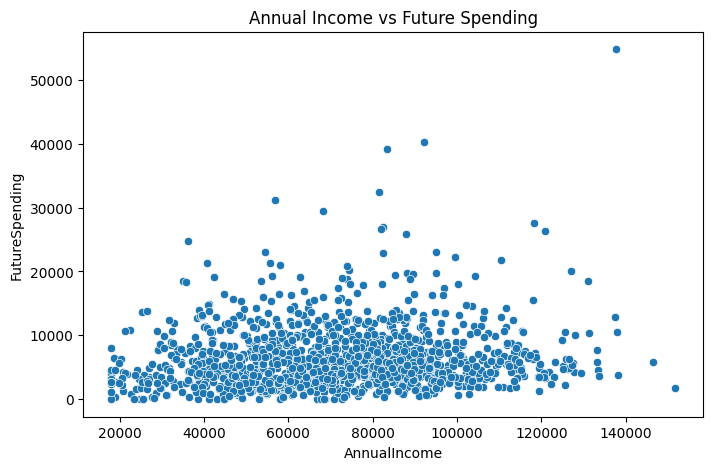

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["AnnualIncome"], y=df["FutureSpending"])
plt.title("Annual Income vs Future Spending")
plt.xlabel("AnnualIncome")
plt.ylabel("FutureSpending")
plt.show()

This chart shows whether higher-income customers tend to spend more in the future.

A positive relationship would suggest income is an important predictor of future spending.

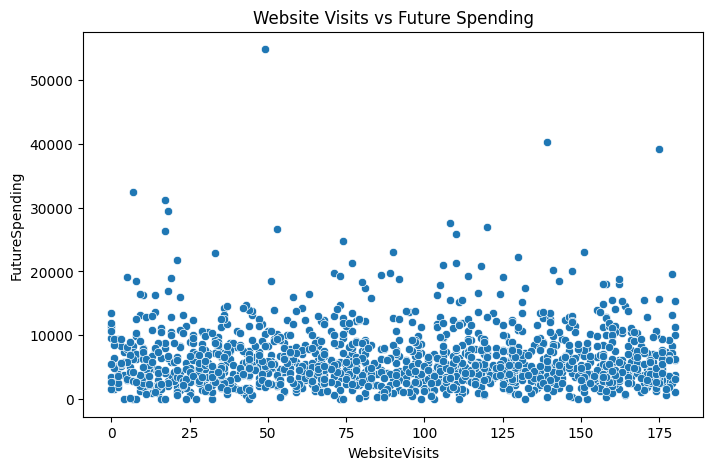

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["WebsiteVisits"], y=df["FutureSpending"])
plt.title("Website Visits vs Future Spending")
plt.xlabel("WebsiteVisits")
plt.ylabel("FutureSpending")
plt.show()

Customers who visit the website more often may be more engaged and more likely to spend in the future.

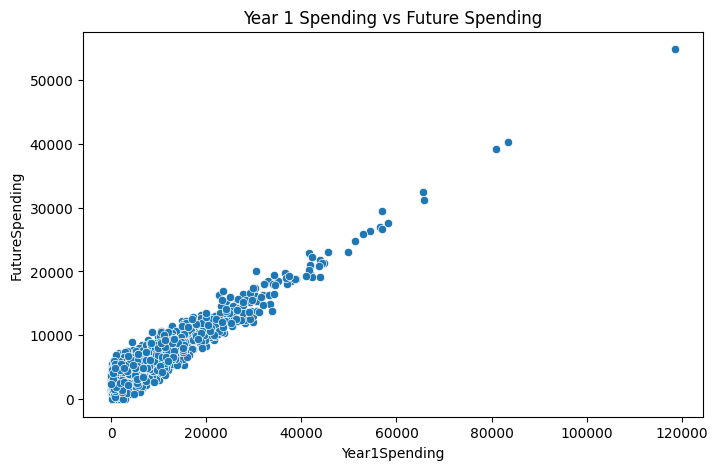

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Year1Spending"], y=df["FutureSpending"])
plt.title("Year 1 Spending vs Future Spending")
plt.xlabel("Year1Spending")
plt.ylabel("FutureSpending")
plt.show()

This relationship helps identify whether past spending is a strong signal of future customer value.

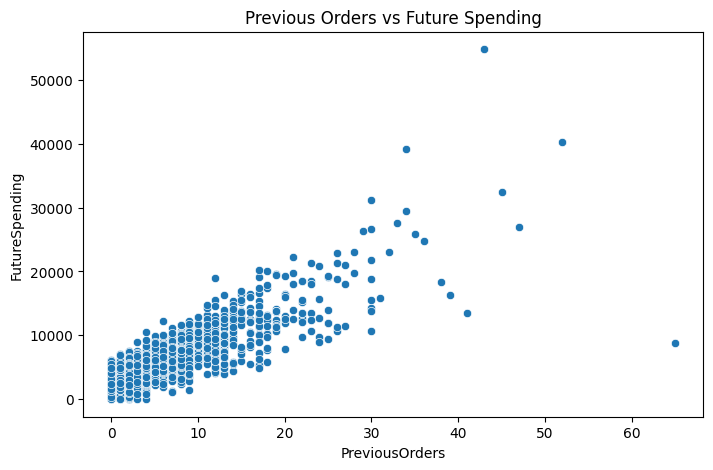

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["PreviousOrders"], y=df["FutureSpending"])
plt.title("Previous Orders vs Future Spending")
plt.xlabel("PreviousOrders")
plt.ylabel("FutureSpending")
plt.show()

Customers with more previous orders may be more loyal and more likely to spend again in the future.

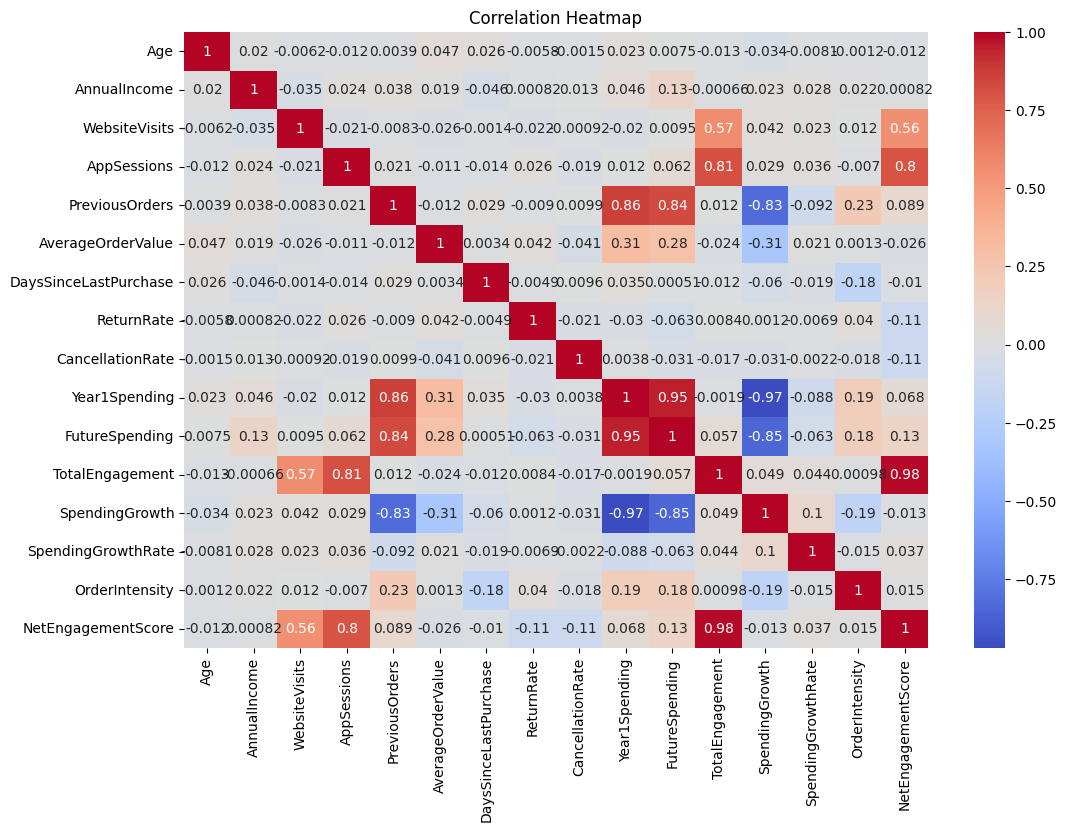

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap helps identify which numerical features are most strongly related to FutureSpending.

Features with stronger positive correlation are likely to be more useful in predicting customer value.

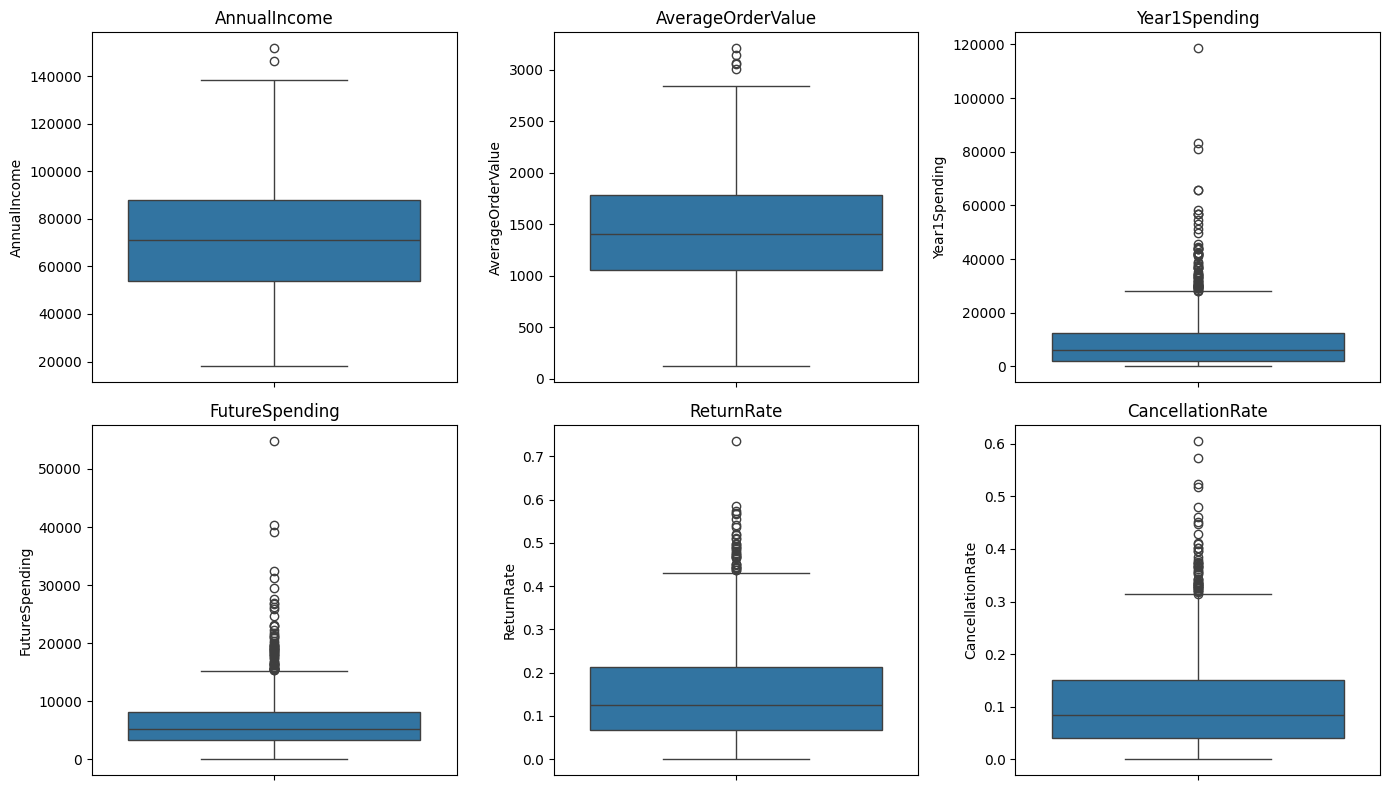

In [13]:
cols = ["AnnualIncome", "AverageOrderValue", "Year1Spending", "FutureSpending", "ReturnRate", "CancellationRate"]

plt.figure(figsize=(14,8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Outliers may represent high-value customers or unusual behavior.

These values should be reviewed carefully because they can affect regression results and segmentation.

In [14]:
q1 = df["FutureSpending"].quantile(0.25)
q3 = df["FutureSpending"].quantile(0.75)

def assign_segment(row):
    if row["FutureSpending"] >= q3 and row["Year1Spending"] >= q3:
        return "High-Value Customer"
    elif row["WebsiteVisits"] >= df["WebsiteVisits"].quantile(0.75) and row["FutureSpending"] < q3:
        return "High-Potential Customer"
    elif row["FutureSpending"] <= q1 and row["WebsiteVisits"] <= df["WebsiteVisits"].quantile(0.25):
        return "Low-Engagement Customer"
    elif row["Year1Spending"] >= q3 and row["DaysSinceLastPurchase"] >= df["DaysSinceLastPurchase"].quantile(0.75):
        return "At-Risk Valuable Customer"
    elif row["FutureSpending"] <= q1:
        return "Low-Value Customer"
    else:
        return "Medium-Value Customer"

df["Segment"] = df.apply(assign_segment, axis=1)

print(df["Segment"].value_counts())

Segment
Medium-Value Customer        481
High-Value Customer          345
High-Potential Customer      260
Low-Value Customer           161
Low-Engagement Customer      107
At-Risk Valuable Customer     46
Name: count, dtype: int64


# Customer Segmentation

Customers were divided into meaningful business segments using rules based on spending, engagement, and recency.

## Segments Used
- High-Value Customer
- Medium-Value Customer
- Low-Value Customer
- High-Potential Customer
- Low-Engagement Customer
- At-Risk Valuable Customer

## Logic
- High spenders with strong history were treated as high value.
- Active but moderate spenders were treated as high potential.
- Low visitors and low spenders were treated as low engagement.
- Valuable customers with long inactivity were treated as at risk.

In [15]:
X = df.drop(columns=["CustomerID", "FutureSpending", "Segment"])
y = df["FutureSpending"]

In [16]:
X = pd.get_dummies(X, columns=["LoyaltyTier", "DiscountUsedLastCampaign"], drop_first=True)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [19]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

In [20]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 2.784056395473981e-11
MSE: 1.5402545053504819e-21
RMSE: 3.9246076305160515e-11
R2: 1.0


In [21]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R2:", dt_r2)

Decision Tree Regressor
MAE: 428.6218928571429
MSE: 458821.9508525
RMSE: 677.3639722132408
R2: 0.9781035714666267


# Model Evaluation

## MAE
Average absolute prediction error.

## MSE
Penalizes larger errors more strongly.

## RMSE
Error in the same unit as FutureSpending.

## R² Score
Explains how much variation in future spending is captured by the model.

A better model has lower MAE, lower RMSE, and higher R².

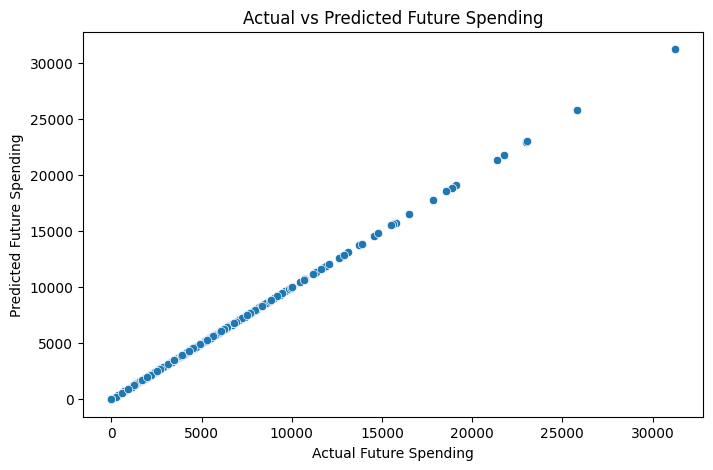

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=lr_pred)
plt.xlabel("Actual Future Spending")
plt.ylabel("Predicted Future Spending")
plt.title("Actual vs Predicted Future Spending")
plt.show()

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [lr_mae, dt_mae],
    "RMSE": [lr_rmse, dt_rmse],
    "R2": [lr_r2, dt_r2]
})

print(results)

               Model           MAE          RMSE        R2
0  Linear Regression  2.784056e-11  3.924608e-11  1.000000
1      Decision Tree  4.286219e+02  6.773640e+02  0.978104


# Final Model Selection

The final model was selected based on MAE, RMSE, and R².

The model with lower error and higher R² was considered more suitable for predicting future customer spending.

Business usefulness mattered more than just raw score values.

# Business Recommendations

## Premium Offers
High-Value Customers should receive premium offers, loyalty benefits, and exclusive services.

## Discounts
Low-value customers and price-sensitive customers can receive discounts to encourage more spending.

## Upselling
High-potential customers should be targeted with upselling and cross-selling offers.

## Re-engagement
At-risk valuable customers should receive re-engagement campaigns and retention incentives.

## Avoid Expensive Offers
Low-engagement customers should not receive expensive offers unless there is clear evidence of improvement potential.

## Increasing LTV
The company can improve LTV by:
- increasing repeat purchases
- improving engagement
- reducing cancellations and returns
- targeting the right customers with the right offers

In [24]:
import os
os.makedirs("outputs", exist_ok=True)
os.makedirs("dataset", exist_ok=True)

In [25]:
df.to_csv("dataset/cleaned_ltv_data.csv", index=False)
results.to_csv("outputs/model_results.csv", index=False)

In [26]:
df["Segment"].value_counts().to_csv("outputs/segment_counts.csv")

In [27]:
import os

os.makedirs("outputs", exist_ok=True)

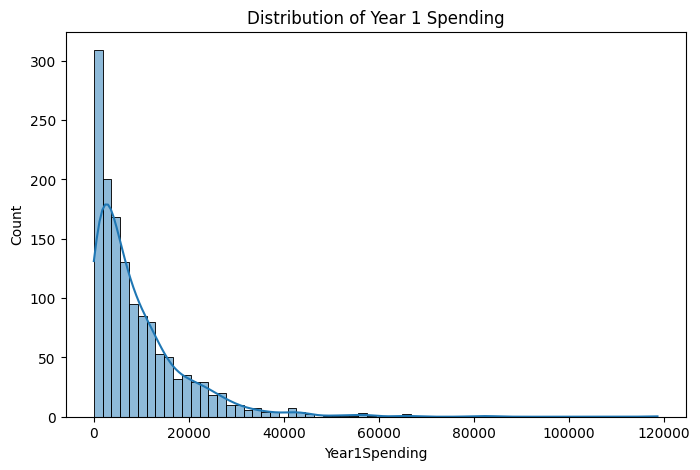

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Year1Spending"],
    kde=True
)

plt.title("Distribution of Year 1 Spending")

plt.xlabel("Year1Spending")
plt.ylabel("Count")

plt.savefig(
    "outputs/year1_spending_distribution.png",
    bbox_inches="tight"
)

plt.show()

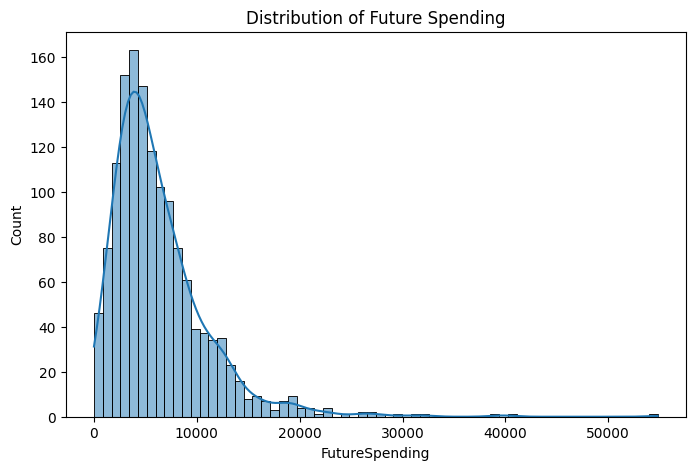

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["FutureSpending"],
    kde=True
)

plt.title("Distribution of Future Spending")

plt.xlabel("FutureSpending")
plt.ylabel("Count")

plt.savefig(
    "outputs/future_spending_distribution.png",
    bbox_inches="tight"
)

plt.show()

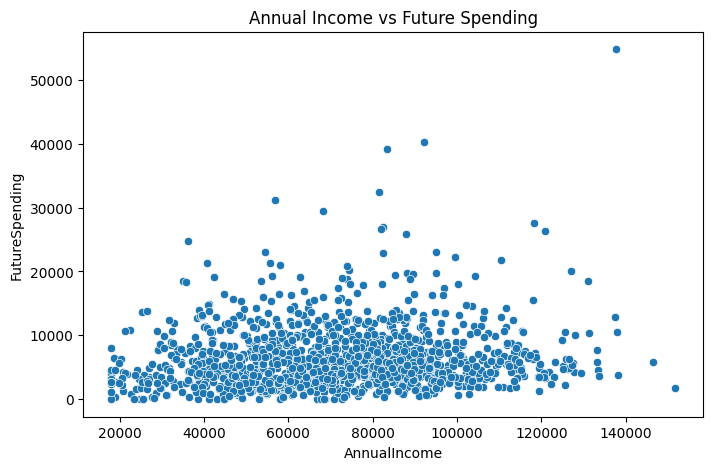

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["AnnualIncome"],
    y=df["FutureSpending"]
)

plt.title("Annual Income vs Future Spending")

plt.xlabel("AnnualIncome")
plt.ylabel("FutureSpending")

plt.savefig(
    "outputs/income_vs_future_spending.png",
    bbox_inches="tight"
)

plt.show()

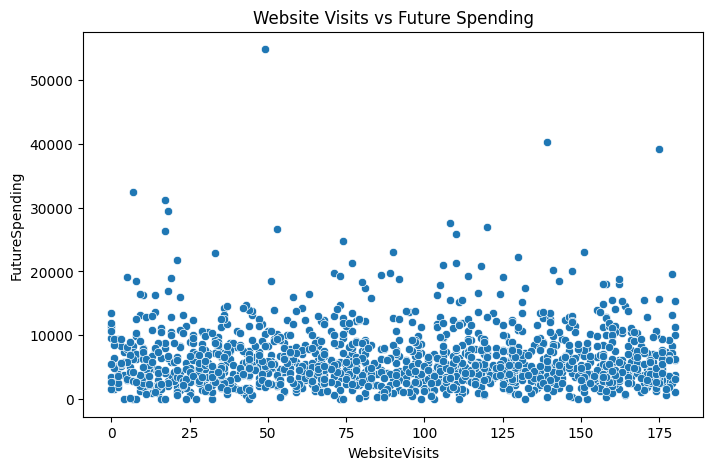

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["WebsiteVisits"],
    y=df["FutureSpending"]
)

plt.title("Website Visits vs Future Spending")

plt.xlabel("WebsiteVisits")
plt.ylabel("FutureSpending")

plt.savefig(
    "outputs/website_visits_vs_future_spending.png",
    bbox_inches="tight"
)

plt.show()

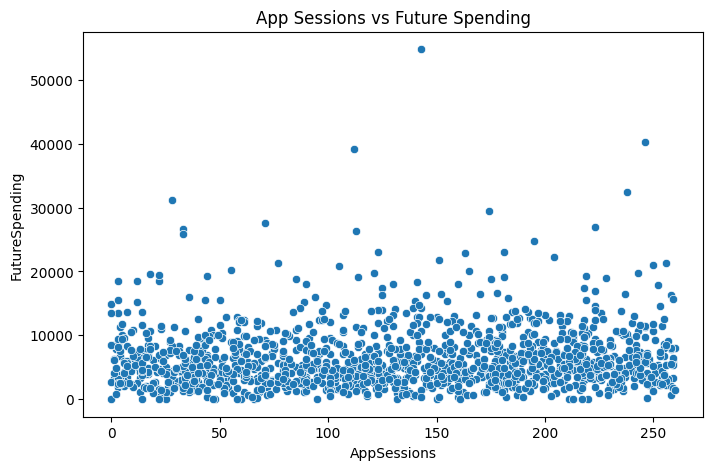

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["AppSessions"],
    y=df["FutureSpending"]
)

plt.title("App Sessions vs Future Spending")

plt.xlabel("AppSessions")
plt.ylabel("FutureSpending")

plt.savefig(
    "outputs/app_sessions_vs_future_spending.png",
    bbox_inches="tight"
)

plt.show()

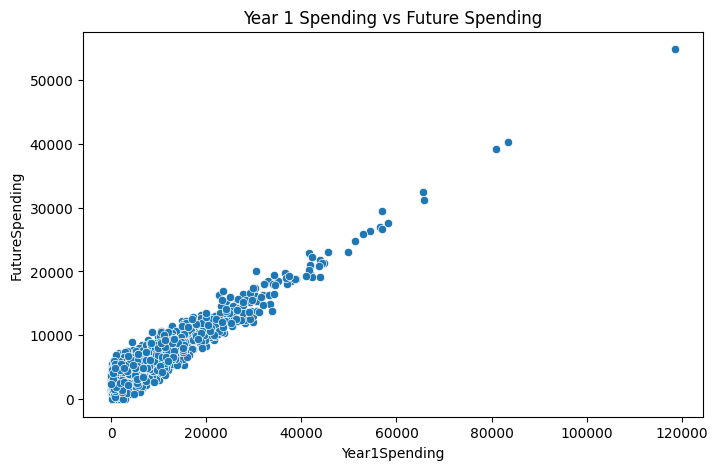

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Year1Spending"],
    y=df["FutureSpending"]
)

plt.title("Year 1 Spending vs Future Spending")

plt.xlabel("Year1Spending")
plt.ylabel("FutureSpending")

plt.savefig(
    "outputs/year1_vs_future_spending.png",
    bbox_inches="tight"
)

plt.show()

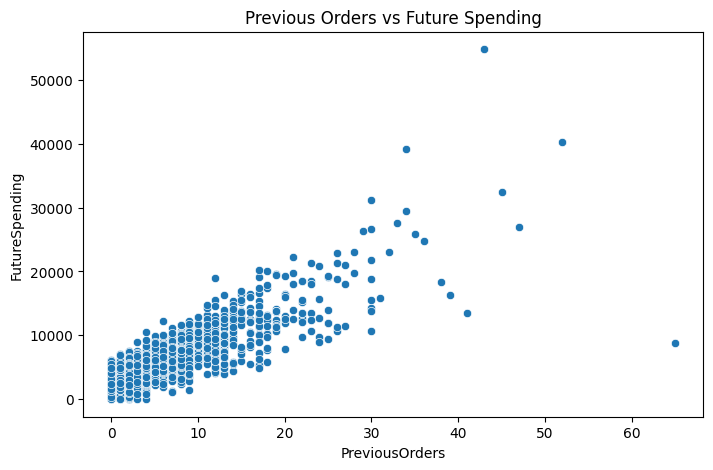

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["PreviousOrders"],
    y=df["FutureSpending"]
)

plt.title("Previous Orders vs Future Spending")

plt.xlabel("PreviousOrders")
plt.ylabel("FutureSpending")

plt.savefig(
    "outputs/orders_vs_future_spending.png",
    bbox_inches="tight"
)

plt.show()

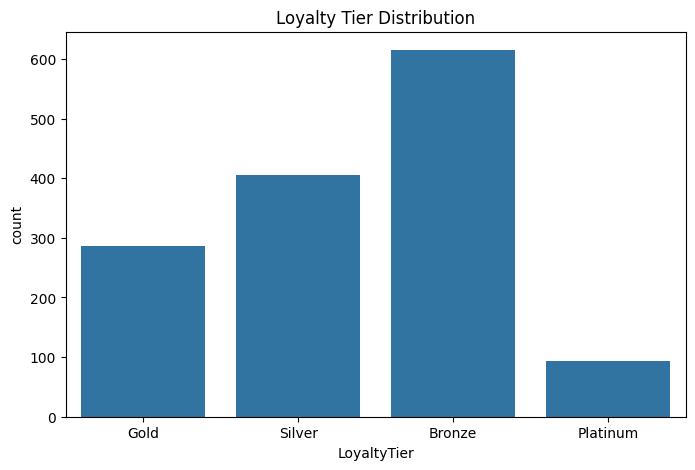

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="LoyaltyTier",
    data=df
)

plt.title("Loyalty Tier Distribution")

plt.savefig(
    "outputs/loyalty_tier_distribution.png",
    bbox_inches="tight"
)

plt.show()

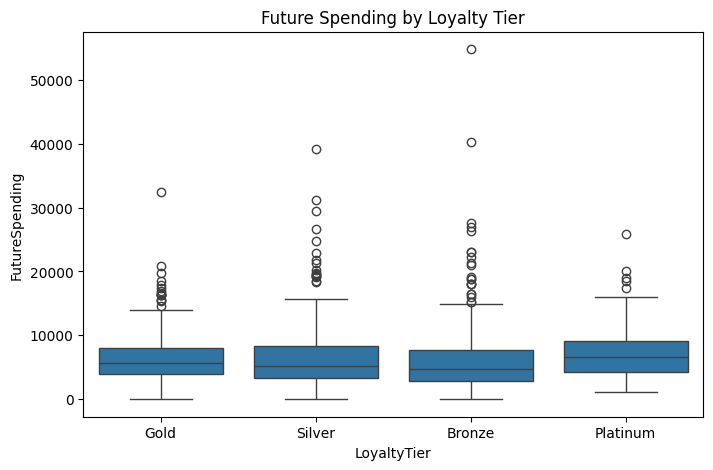

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="LoyaltyTier",
    y="FutureSpending",
    data=df
)

plt.title("Future Spending by Loyalty Tier")

plt.savefig(
    "outputs/future_spending_by_loyalty.png",
    bbox_inches="tight"
)

plt.show()

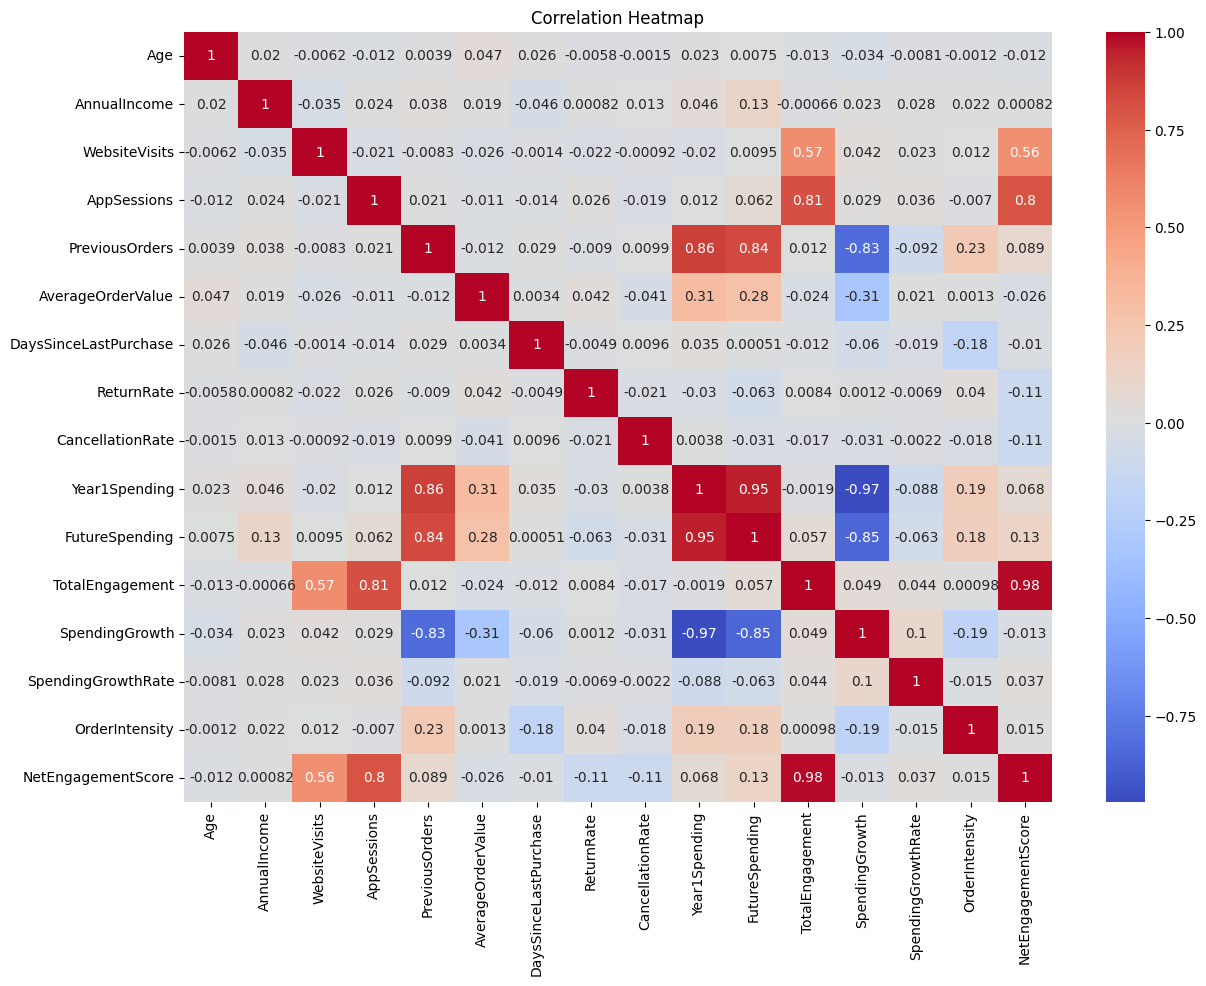

In [38]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "outputs/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

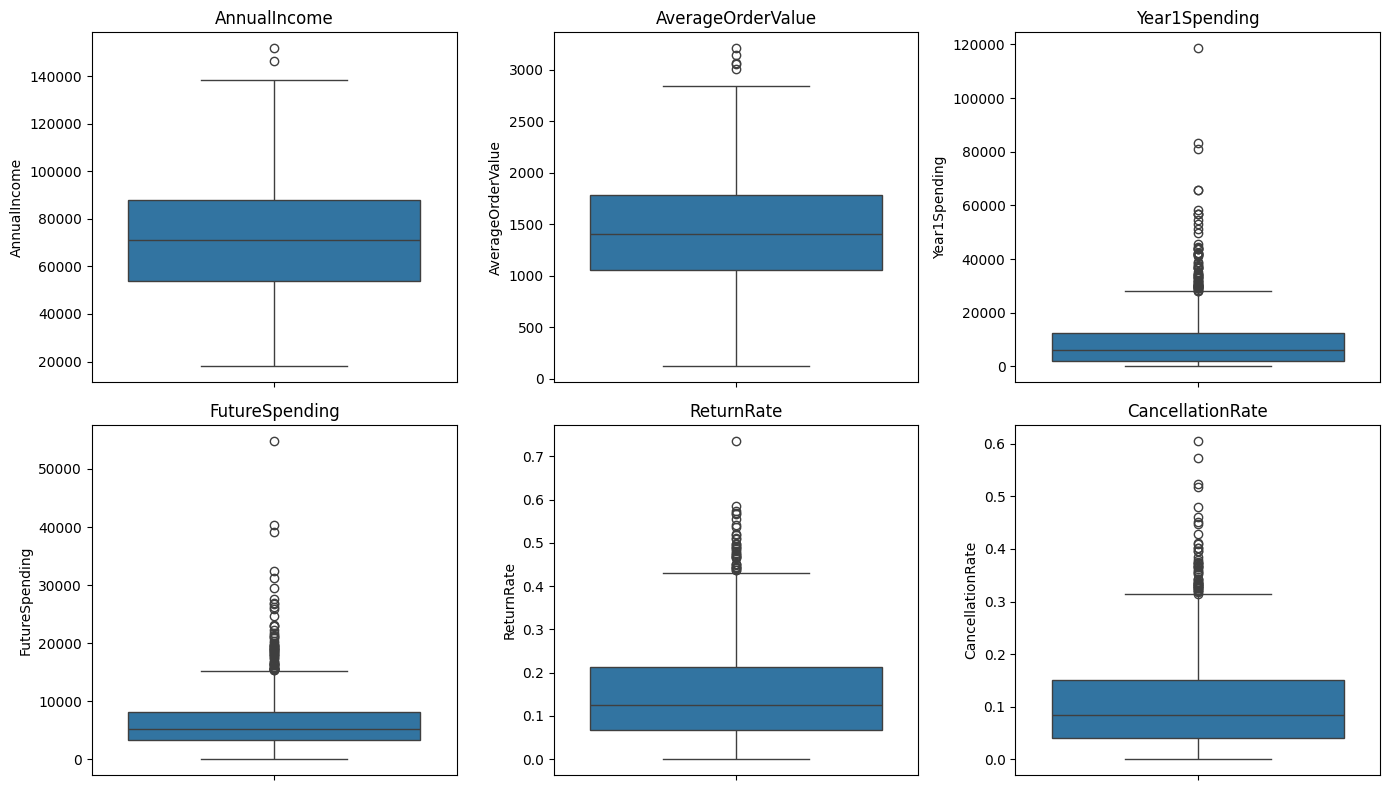

In [39]:
cols = [
    "AnnualIncome",
    "AverageOrderValue",
    "Year1Spending",
    "FutureSpending",
    "ReturnRate",
    "CancellationRate"
]

plt.figure(figsize=(14,8))

for i, col in enumerate(cols, 1):

    plt.subplot(2, 3, i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.savefig(
    "outputs/outlier_boxplots.png",
    bbox_inches="tight"
)

plt.show()

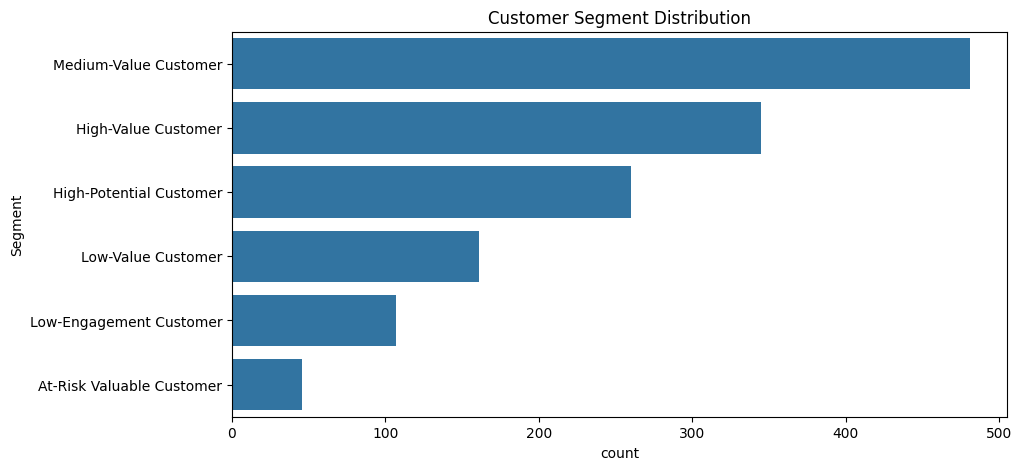

In [40]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="Segment",
    data=df,
    order=df["Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")

plt.savefig(
    "outputs/customer_segments.png",
    bbox_inches="tight"
)

plt.show()

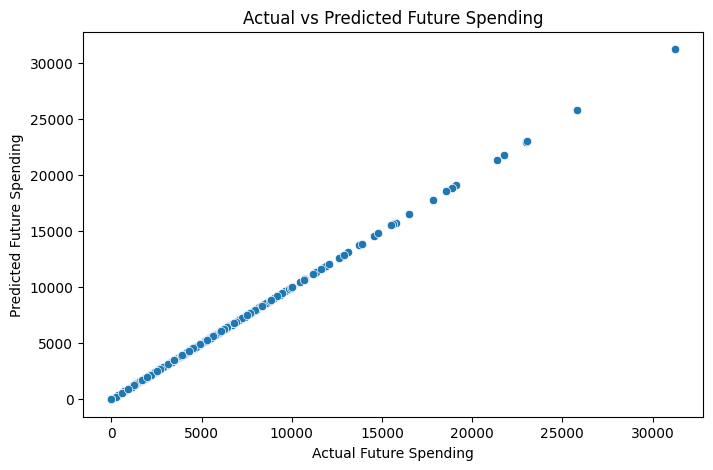

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=lr_pred
)

plt.xlabel("Actual Future Spending")
plt.ylabel("Predicted Future Spending")

plt.title("Actual vs Predicted Future Spending")

plt.savefig(
    "outputs/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

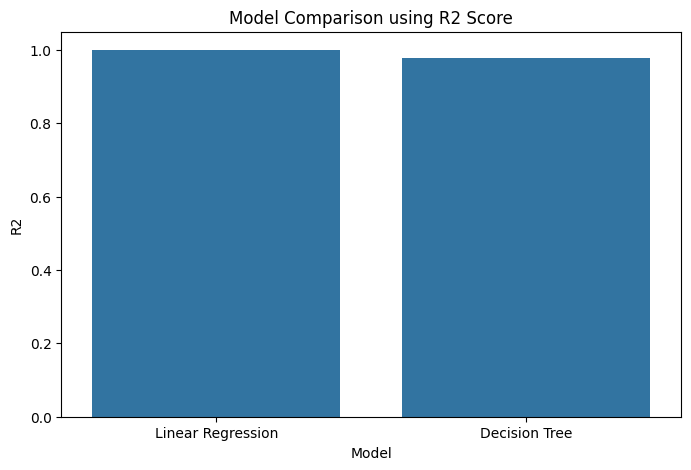

In [42]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "RMSE": [lr_rmse, dt_rmse],
    "R2": [lr_r2, dt_r2]
})

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2",
    data=results
)

plt.title("Model Comparison using R2 Score")

plt.savefig(
    "outputs/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

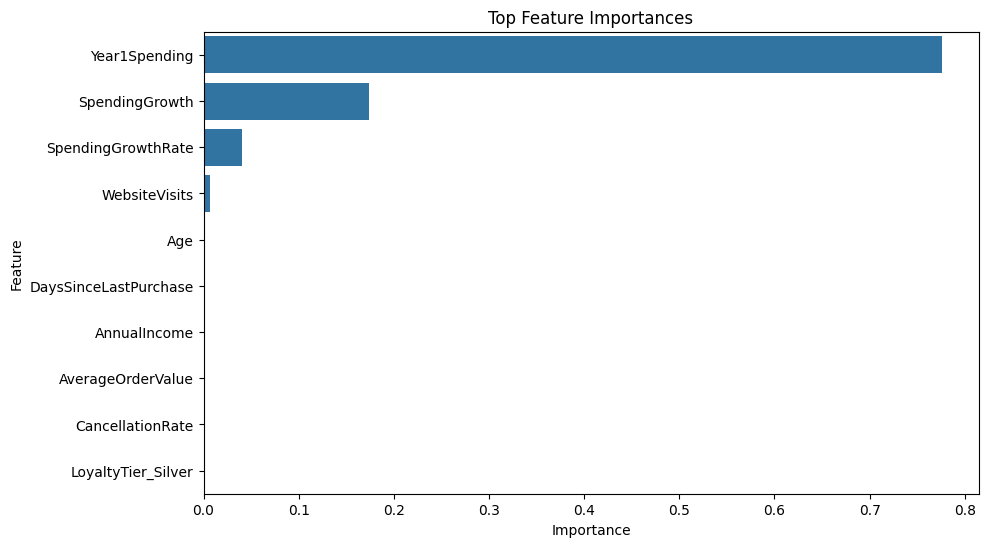

In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top Feature Importances")

plt.savefig(
    "outputs/feature_importance.png",
    bbox_inches="tight"
)

plt.show()